In [37]:
## importing liberries

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## liberries for preprocessing

from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [17]:
## load data 
df = pd.read_csv(r"C:\Users\Shlok\sml_project\artifact\train_data.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group D,master's degree,standard,none,62,70,75
1,female,group C,bachelor's degree,free/reduced,completed,66,83,83
2,female,group D,some college,free/reduced,none,79,89,86
3,male,group C,master's degree,free/reduced,none,61,67,66
4,male,group E,high school,standard,none,73,64,57


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       800 non-null    str  
 1   race/ethnicity               800 non-null    str  
 2   parental level of education  800 non-null    str  
 3   lunch                        800 non-null    str  
 4   test preparation course      800 non-null    str  
 5   math score                   800 non-null    int64
 6   reading score                800 non-null    int64
 7   writing score                800 non-null    int64
dtypes: int64(3), str(5)
memory usage: 50.1 KB


In [19]:
## Describing data

df.describe()

,math score,reading score,writing score
count,800.000000,800.000000,800.000000
mean,66.496250,69.555000,68.456250
std,15.024302,14.461532,15.085342
min,8.000000,24.000000,15.000000
25%,57.000000,60.000000,58.000000
50%,66.000000,70.000000,69.000000
75%,77.000000,80.000000,79.000000
max,100.000000,100.000000,100.000000


In [20]:
## datatype

df.dtypes

gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

In [21]:
## shape(r,c)

df.shape

(800, 8)

In [22]:
## duplicated values 

df.duplicated().sum()

np.int64(0)

In [23]:
## missing values

df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

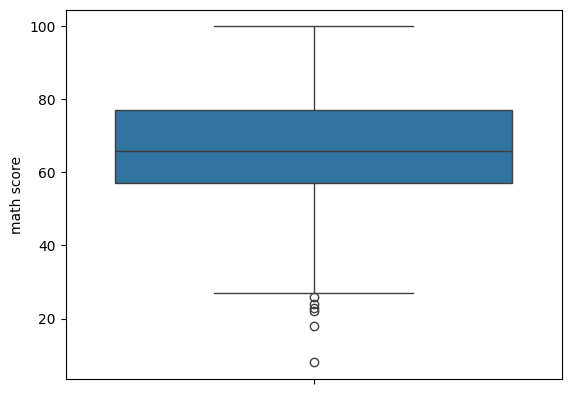

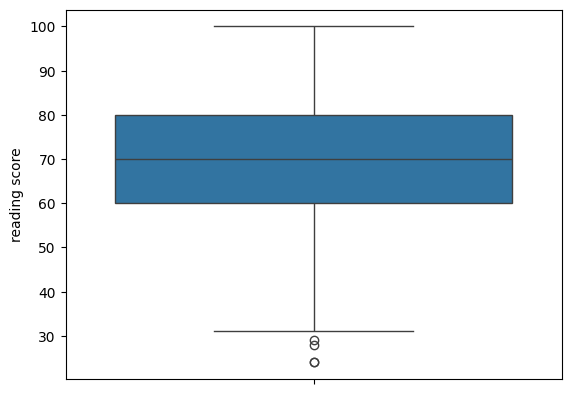

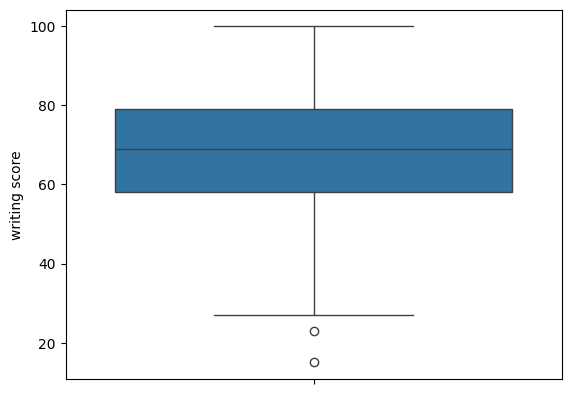

In [24]:
## check outliers --> whiskers and boxplot method

for i in df.select_dtypes(include = ["float64","int64"]):
    sns.boxplot(df[i])
    plt.show()

In [25]:
df["overall_score"] = df["math score"]+ df["reading score"] + df["writing score"]

In [26]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,overall_score
0,female,group D,master's degree,standard,none,62,70,75,207
1,female,group C,bachelor's degree,free/reduced,completed,66,83,83,232
2,female,group D,some college,free/reduced,none,79,89,86,254
3,male,group C,master's degree,free/reduced,none,61,67,66,194
4,male,group E,high school,standard,none,73,64,57,194


In [27]:
df.gender.value_counts()

gender
female    421
male      379
Name: count, dtype: int64

In [28]:
df["race/ethnicity"].value_counts()

race/ethnicity
group C    260
group D    202
group B    153
group E    116
group A     69
Name: count, dtype: int64

In [30]:
## one hot encoding help to convert categorical data into numerical data
cat_one = ["gender","lunch","test preparation course"]
ohe = OneHotEncoder(drop="first")
for i in cat_one:
    df[i] = ohe.fit_transform(df[[i]]).toarray()

In [31]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,overall_score
0,0.0,group D,master's degree,1.0,1.0,62,70,75,207
1,0.0,group C,bachelor's degree,0.0,0.0,66,83,83,232
2,0.0,group D,some college,0.0,1.0,79,89,86,254
3,1.0,group C,master's degree,0.0,1.0,61,67,66,194
4,1.0,group E,high school,1.0,1.0,73,64,57,194


In [33]:
## label encoding help to convert categorical data into numerical data
cat_label = ["race/ethnicity","parental level of education"]
enco = LabelEncoder()
for i in cat_label:
    df[i] = enco.fit_transform(df[i])


In [34]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,overall_score
0,0.0,3,3,1.0,1.0,62,70,75,207
1,0.0,2,1,0.0,0.0,66,83,83,232
2,0.0,3,4,0.0,1.0,79,89,86,254
3,1.0,2,3,0.0,1.0,61,67,66,194
4,1.0,4,2,1.0,1.0,73,64,57,194


In [35]:
## separating features and target variable
X = df.drop(columns = ["overall_score"])
y = df["overall_score"]

In [38]:
## Normalization 
normal = MinMaxScaler()
x = normal.fit_transform(X)

In [39]:
## train test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [41]:
## model building
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
model = LinearRegression()
model.fit(x_train,y_train)
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)
print("R2 score for train data is ",r2_score(y_train,y_pred_train))
print("R2 score for test data is ",r2_score(y_test,y_pred_test))
print("MAE for train data is ",mean_absolute_error(y_train,y_pred_train))
print("MAE for test data is ",mean_absolute_error(y_test,y_pred_test))
print("MSE for train data is ",mean_squared_error(y_train,y_pred_train))




R2 score for train data is  1.0
R2 score for test data is  1.0
MAE for train data is  6.337153024560393e-14
MAE for test data is  6.24389429049188e-14
MSE for train data is  4.7003488176688765e-27


In [44]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(x_train,y_train)
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)
print("R2 score for train data is ",r2_score(y_train,y_pred_train))
print("R2 score for test data is ",r2_score(y_test,y_pred_test))
print("MAE for train data is ",mean_absolute_error(y_train,y_pred_train))
print("MAE for test data is ",mean_absolute_error(y_test,y_pred_test))
print("MSE for train data is ",mean_squared_error(y_train,y_pred_train))
print("MSE for test data is ",mean_squared_error(y_test,y_pred_test))

R2 score for train data is  1.0
R2 score for test data is  0.9871816355016827
MAE for train data is  0.0
MAE for test data is  3.4625
MSE for train data is  0.0
MSE for test data is  23.4


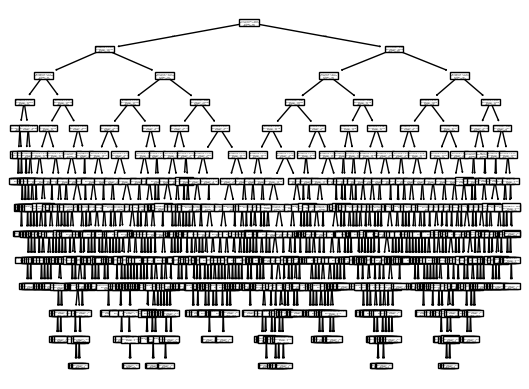

In [48]:
from sklearn.tree import plot_tree
plot_tree(model,feature_names =df.drop(columns = ["overall_score"]).columns)
plt.show()  

In [57]:
## hyperparameter tuning
from sklearn.model_selection import GridSearchCV
param_grid= { 'ccp_alpha' : [0.1,1,10,100],
             'min_samples_split' : [2,5,10],
             'min_samples_leaf' : [1,2,4],
             "max_depth" : [None,10,20,30]
             }
for i in param_grid:
    dtree = DecisionTreeRegressor()
    grid_search = GridSearchCV(estimator = dtree,param_grid = param_grid,cv = 5)
    grid_search.fit(x_train,y_train)
    print("Best hyperparameters: ",grid_search.best_params_)
    best_model = grid_search.best_estimator_
    y_pred_train = best_model.predict(x_train)
    y_pred_test = best_model.predict(x_test)
    print("R2 score for train data is ",r2_score(y_train,y_pred_train))
    print("R2 score for test data is ",r2_score(y_test,y_pred_test))
    print("MAE for train data is ",mean_absolute_error(y_train,y_pred_train))
    print("MAE for test data is ",mean_absolute_error(y_test,y_pred_test))  
    print("MSE for train data is ",mean_squared_error(y_train,y_pred_train))
    print("MSE for test data is ",mean_squared_error(y_test,y_pred_test))

Best hyperparameters:  {'ccp_alpha': 0.1, 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2}
R2 score for train data is  0.9966840112910937
R2 score for test data is  0.9833024690029454
MAE for train data is  1.9310134310134317
MAE for test data is  4.2549279193029195
MSE for train data is  5.917306326486014
MSE for test data is  30.481441324466164
Best hyperparameters:  {'ccp_alpha': 0.1, 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2}
R2 score for train data is  0.9966950560952091
R2 score for test data is  0.9851019234451408
MAE for train data is  1.928122806013431
MAE for test data is  3.975481896575647
MSE for train data is  5.897597125097125
MSE for test data is  27.196526626268916
Best hyperparameters:  {'ccp_alpha': 0.1, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}
R2 score for train data is  0.9963336494791524
R2 score for test data is  0.984079271020376
MAE for train data is  2.0101540560134312
MAE for test data is  4.1872716693

In [58]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_dist = { 'ccp_alpha' : randint(0,100),
                'min_samples_split' : randint(2,10),
                'min_samples_leaf' : randint(1,4),
                "max_depth" : [None,10,20,30]
             }
dtree = DecisionTreeRegressor()
random_search = RandomizedSearchCV(estimator = dtree,param_distributions = param_dist,cv = 5,n_iter = 10,random_state = 42)
random_search.fit(x_train,y_train)
print("Best hyperparameters: ",random_search.best_params_)
best_model = random_search.best_estimator_
y_pred_train = best_model.predict(x_train)
y_pred_test = best_model.predict(x_test)
print("R2 score for train data is ",r2_score(y_train,y_pred_train))
print("R2 score for test data is ",r2_score(y_test,y_pred_test))
print("MAE for train data is ",mean_absolute_error(y_train,y_pred_train))
print("MAE for test data is ",mean_absolute_error(y_test,y_pred_test))
print("MSE for train data is ",mean_squared_error(y_train,y_pred_train))
print("MSE for test data is ",mean_squared_error(y_test,y_pred_test))


Best hyperparameters:  {'ccp_alpha': 1, 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2}
R2 score for train data is  0.9856458687452252
R2 score for test data is  0.9746251092658131
MAE for train data is  3.9268863295878105
MAE for test data is  5.32050689571007
MSE for train data is  25.614620296190417
MSE for test data is  46.32201270746523


In [59]:
## best hyperparameters are {'ccp_alpha': 0, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
dtree_final = DecisionTreeRegressor(ccp_alpha = 0, max_depth = None, min_samples_leaf = 1, min_samples_split = 2)
dtree_final.fit(x_train,y_train)
y_pred_train = dtree_final.predict(x_train)
y_pred_test = dtree_final.predict(x_test)
print("R2 score for train data is ",r2_score(y_train,y_pred_train))
print("R2 score for test data is ",r2_score(y_test,y_pred_test))
print("MAE for train data is ",mean_absolute_error(y_train,y_pred_train))
print("MAE for test data is ",mean_absolute_error(y_test,y_pred_test))
print("MSE for train data is ",mean_squared_error(y_train,y_pred_train))
print("MSE for test data is ",mean_squared_error(y_test,y_pred_test))


R2 score for train data is  1.0
R2 score for test data is  0.9878800720288347
MAE for train data is  0.0
MAE for test data is  3.5125
MSE for train data is  0.0
MSE for test data is  22.125
